# Машинное обучение, ФКН ВШЭ

# Практическое задание 6. Бустинговое

## Общая информация

Дата выдачи: 12.12.2024

Мягкий дедлайн: 22.12.2024 23:59 MSK

Жёсткий дедлайн: 22.12.2024 23:59 MSK

## Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.

## Формат сдачи
Задания сдаются через систему anytask. Посылка должна содержать:
* Ноутбук homework-practice-06-Username.ipynb

Username — ваша фамилия на латинице

## О задании

В этом задании вам предстоит вручную запрограммировать один из самых мощных алгоритмов машинного обучения — бустинг. Однако с большой силой приходит и большая ответственность, так что заодно научимся, как его правильно готовить

In [70]:
from warnings import filterwarnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.sparse import load_npz
from sklearn.model_selection import train_test_split

sns.set(style='darkgrid')
filterwarnings('ignore')

In [10]:
X = load_npz('x.npz')
y = np.load('y.npy')

In [11]:
X

<23532x169 sparse matrix of type '<class 'numpy.float64'>'
	with 148920 stored elements in Compressed Sparse Row format>

In [12]:
y

array([1, 1, 0, ..., 0, 0, 1], dtype=int64)

Разделим на обучающую, валидационную и тестовую выборки (оставьте `random_state=1337` для воспроизводимости).

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1337)
X_test, X_valid, y_test, y_valid = train_test_split(X_test, y_test, test_size=0.5, random_state=1337)

X_train.shape, X_valid.shape, X_test.shape

((18825, 169), (2354, 169), (2353, 169))

---

## Задание 1. Базовый градиентный бустинг (4 балла)

Первая часть посвящена реализации собственного градиентного бустинга. Обращаем внимание, что пользоваться готовыми реализациями <font color='lightcoral'>**нельзя**</font>, если специально не оговорено. На все <font color='plum'>**вопросы**</font> должен быть <font color='plum'>**ответ**</font>. В заданиях есть референсы для параметров, которые нужно сделать, на случай, если объяснение из ноутбука непонятно, тогда советуем обратиться к соответствующей документации

Вам нужно дописать код в файлике `boosting.py`. Для вас уже подготовлен шаблон класса `Boosting`, вы можете менять его по своему усмотрению.

### Инструкции для функций:

#### `__init__`

Обязательные параметры:
 — `base_model_class` — класс базовой модели нашего бустинга
 — `base_model_params` — словарь с гиперпараметрами для базовой модели
 — `n_estimators` — какое количество базовых моделей нужно обучить
 — `learning_rate` — темп обучения, должен быть из полуинтервала $(0, 1]$

#### `fit`

В `fit` приходит выборка, на которой мы обучаем новые базовые модели

Сначала нам нужно сделать какую-то нулевую модель, сделать предсказания (в шаблоне это нулевая модель, соответственно предсказания это просто `np.zeros`). После этого нужно обучить `n_estimators` базовых моделей (как и на что обучаются базовые модели смотрите в лекциях и семинарах). После каждой обученной базовой модели мы должны обновить текущие предсказания, посчитать ошибку на выборке (используем `loss_fn` для этого) и найти новую оптимальную гамму

После всего цикла обучения надо нарисовать график (если `plot=True`).

#### `partial_fit`

В `partial_fit` приходит обучающая выборка, на которую обучается новая базовая модель

#### `predict_proba`

В `predict_proba` приходит любая выборка, нужно предсказать вероятности для неё. Суммируем предсказания базовых моделей на этой выборке (не забываем про гаммы) и накидываем сигмоиду

#### `plot_history`

В `plot_history` приходит любая выборка, для которой последовательно считаются значения функции потерь и/или любой метрики, которую вы хотите посчитать, путем последовательного применения базовых моделей. Можно делать сразу во время обучения, можно делать иначе

In [14]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
%autoreload 2

from boosting import Boosting, roc_pr_curves

### Проверка кода

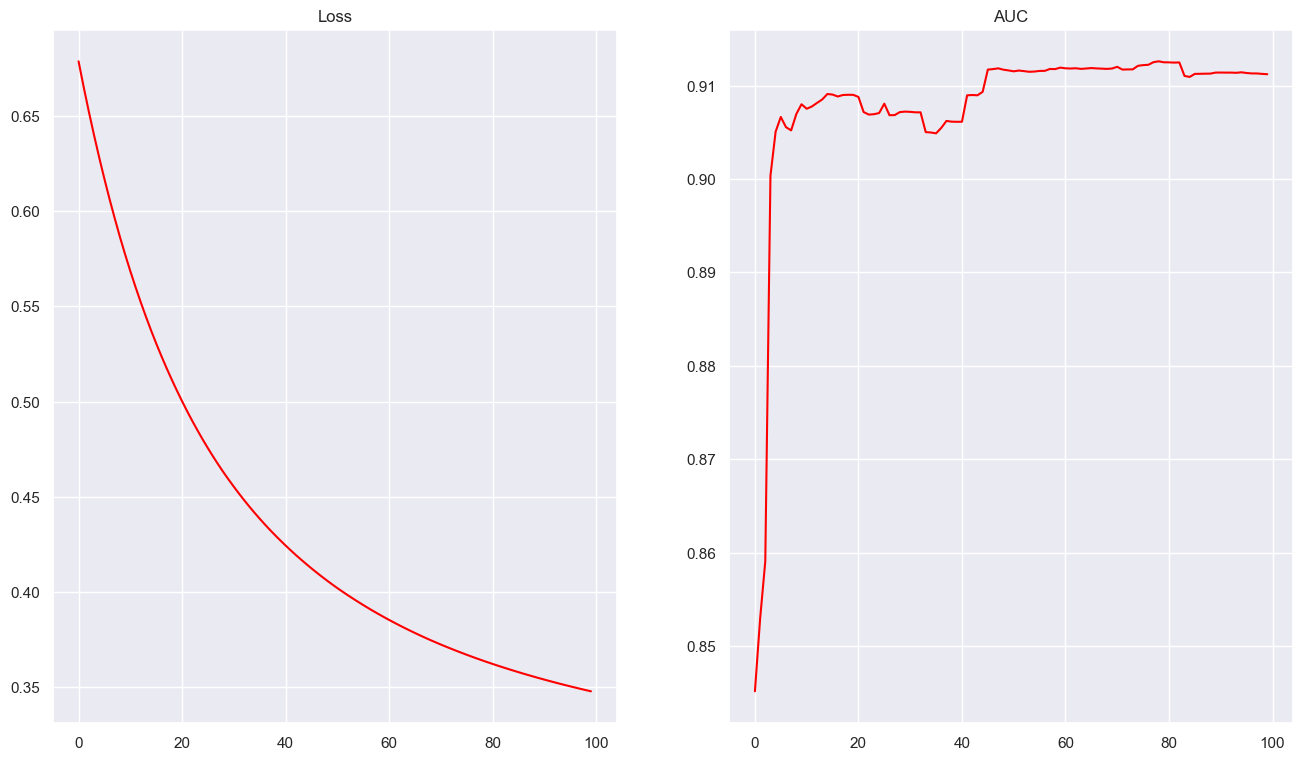

Train ROC-AUC 0.9998
Valid ROC-AUC 0.9070
Test ROC-AUC 0.9050


In [16]:
boosting = Boosting(n_estimators=100)

boosting.fit(X_train, y_train)
boosting.plot_history(X_valid, y_valid)

assert len(boosting.models) == boosting.n_estimators
assert len(boosting.gammas) == boosting.n_estimators

assert boosting.predict_proba(X_test).shape == (X_test.shape[0], 2)

print(f'Train ROC-AUC {boosting.score(X_train, y_train):.4f}')
print(f'Valid ROC-AUC {boosting.score(X_valid, y_valid):.4f}')
print(f'Test ROC-AUC {boosting.score(X_test, y_test):.4f}')

---

## Задание 2. Имплементация гиперпараметров (2.5 балла + 3.5 бонус)

Бустинг, как метод агрегации, предлагает несколько вариантов регуляризации безотносительно базовой модели. В этом пункте предлагается имплементировать часть из них. При необходимости можете обратиться к реализациям в вашей любимой библиотеке, там могут быть дополнительные пояснения и/или ссылки на оригинальные статьи

<font color='lightcoral'>**Важно!**</font> После добавления каждого параметра проверьте, как это повлияет на качество. Специально крутить параметры не нужно, но важно увидеть, что перформанс модели изменился, в худшую или в лучшую сторону, для этого какие-то параметры нужны, пусть и от балды, <font color='lightcoral'>**дефолтные параметры не подойдут**</font>, они скорее для референса. Лучше всего это видно по графикам обучения <font color='lightcoral'>**на трейне и валидации**</font>, рекомендуется смотрить именно на них

### 2.1. Борьба с переобучением (0.5 балла)

Как известно, бустинги бывают склонны к переобучению. Чтобы этого не допустить, можно контролировать процесс обучения и проверять критерий останова на валидации. Реализуйте такую процедуру, не забудьте, что всю предобработку, что вы будете делать для трейна, нужно будет повторить на валидации

| <font color='lightblue'>XGBoost</font> | <font color='lightgreen'>LightGBM</font> | <font color='palegoldenrod'>CatBoost</font> |
| --- | --- | --- |
| <td colspan=3>`early_stopping_rounds`, `eval_set` |

Добавьте параметры:
- `early_stopping_rounds: int | None = 0` — число раундов для критерия останова. Если качество ухудшается на протяжении всех раундов подряд, останавливаем обучение
- `X_val`, `y_val` или `eval_set: Tuple[np.ndarray] | None = None` — валидацонная выборка, на которой будем проверять переобучение

In [17]:
# Короче как бы я не старалась не вышло заставить расти loss на валидации, поэтому я добавила в критерии падение AUC 

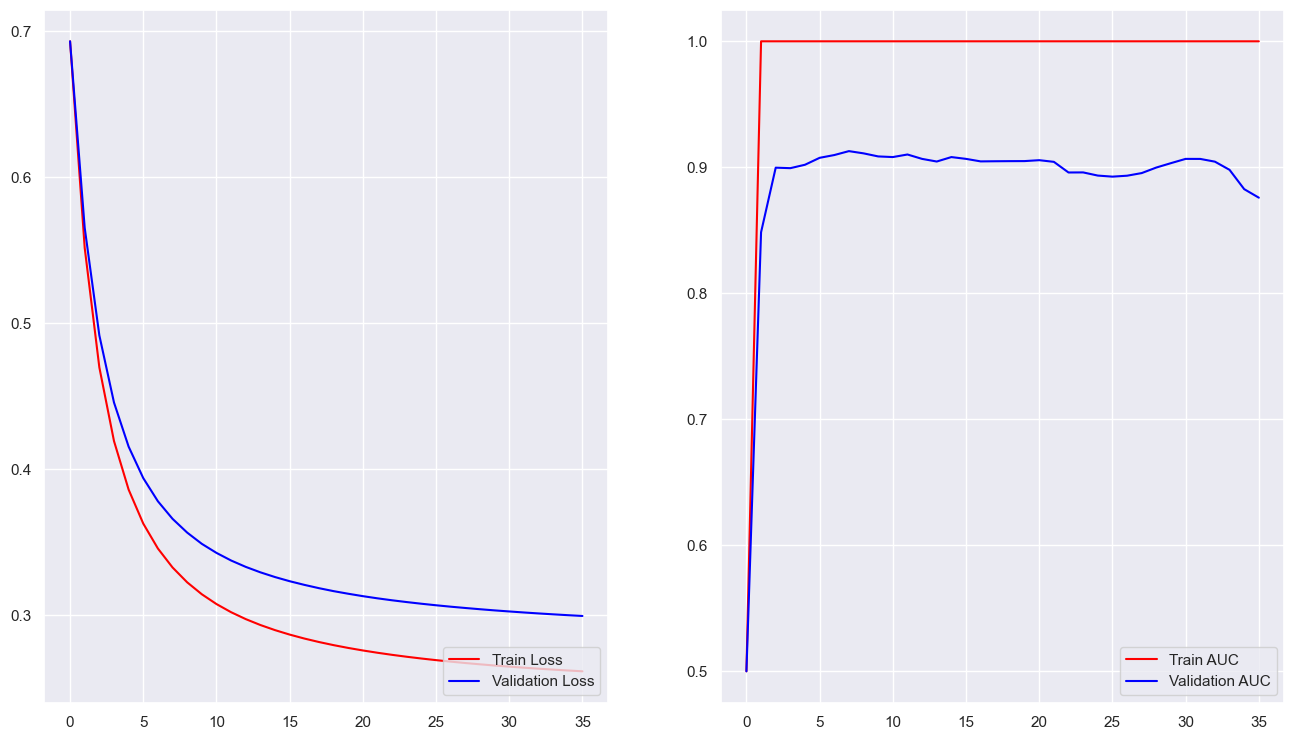

Train ROC-AUC 0.9998
Valid ROC-AUC 0.8583
Test ROC-AUC 0.8488


In [18]:
base_model_param = {'max_depth': 250}

boosting = Boosting(n_estimators=5000, base_model_params=base_model_param, early_stopping_rounds=5, learning_rate=1)

boosting.fit(X_train, y_train, X_valid, y_valid, plot=True, plot_process=True)

print(f'Train ROC-AUC {boosting.score(X_train, y_train):.4f}')
print(f'Valid ROC-AUC {boosting.score(X_valid, y_valid):.4f}')
print(f'Test ROC-AUC {boosting.score(X_test, y_test):.4f}')

### Бонус. Бустинг линейных моделей (0.5 балла)

**<font color='plum'>Вопрос:** что произойдет при ансамблировании линейных моделей? Имеет ли это смысл?</font>

<font color='plum'>**Ответ:** мы обучаем линейные модели приближать остатки друг за другом с учетом функции потерь, и затем с некоторым весом складываем - выходит линейная комбинация линейных моделей. По факту - это все еще линейная модель. Допустим, у нас было две итерации: $b_1(x) = w_0 + w_1x$ и $b_2(x) = a_0 + a_1x$, когда мы их сложим, то получим еще одну линейную модель: $b_1(x) + b_2(x) = (a_0 + w_0) + (w_1 + a_1)x$. Можно пробовать добавлять нелинейность - тем не менее не очень ясно как именно это делать в алгоритме бустинга. Можно также попробовать подавать на выход бустрапированное множество признаков, но по идее должна все еще получится линейная модель.</font>

Давайте убедимся. Обучите бустинг, где в качестве базовой модели будет линейная регрессия. Обязательно сохраните историю функции потерь и зафиксируйте время обучения. Можно взять уже готовый из <font color='lightblue'>**XGBoost**</font>, но будьте готовы разобраться с тем, как оттуда достать историю обучения

| <font color='lightblue'>XGBoost</font> | <font color='lightgreen'>LightGBM</font> | <font color='palegoldenrod'>CatBoost</font> |
| --- | --- | --- |
| `XGBClassifier(booster="gblinear")` | — | — |

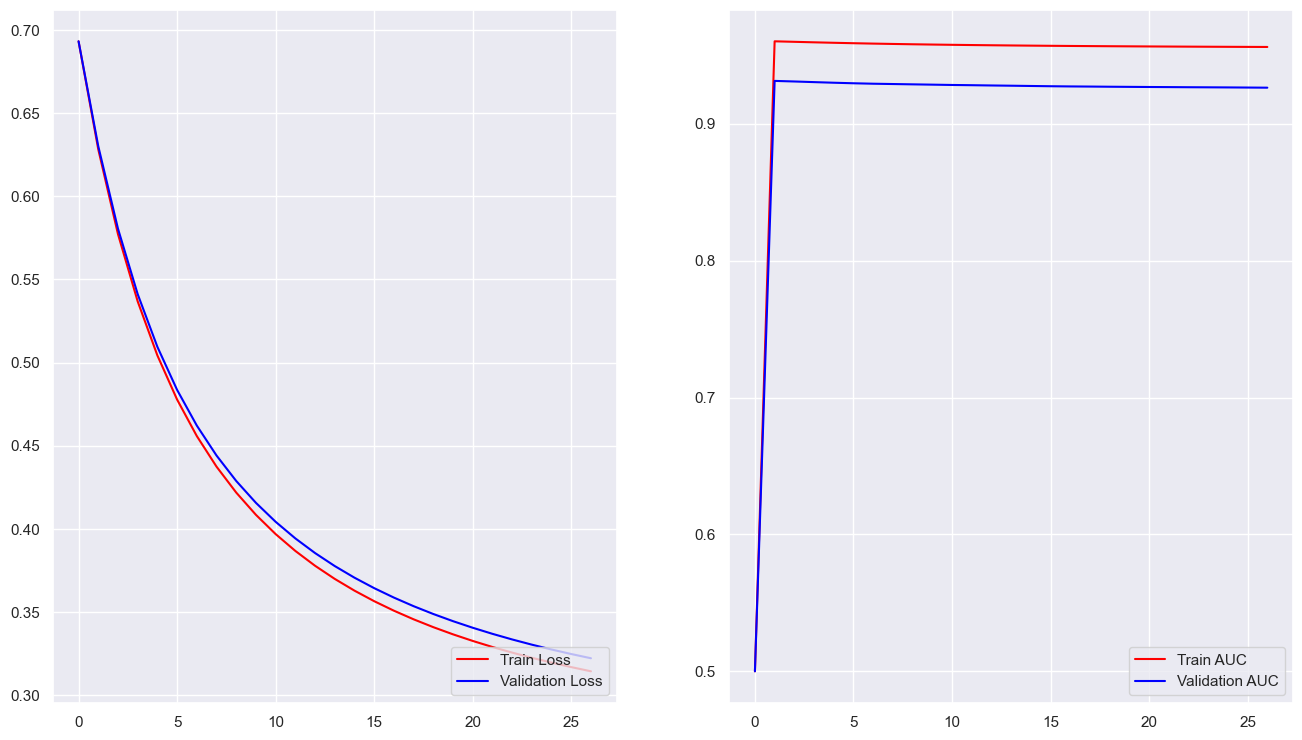

Train ROC-AUC 0.9560
Valid ROC-AUC 0.9336
Test ROC-AUC 0.9263


In [19]:
from sklearn.linear_model import LinearRegression

boosting = Boosting(base_model_class = LinearRegression, n_estimators=150, early_stopping_rounds=25, learning_rate=0.5)
boosting.fit(X_train, y_train, X_test, y_test, plot_process=True, plot=True)

print(f'Train ROC-AUC {boosting.score(X_train, y_train):.4f}')
print(f'Valid ROC-AUC {boosting.score(X_valid, y_valid):.4f}')
print(f'Test ROC-AUC {boosting.score(X_test, y_test):.4f}')

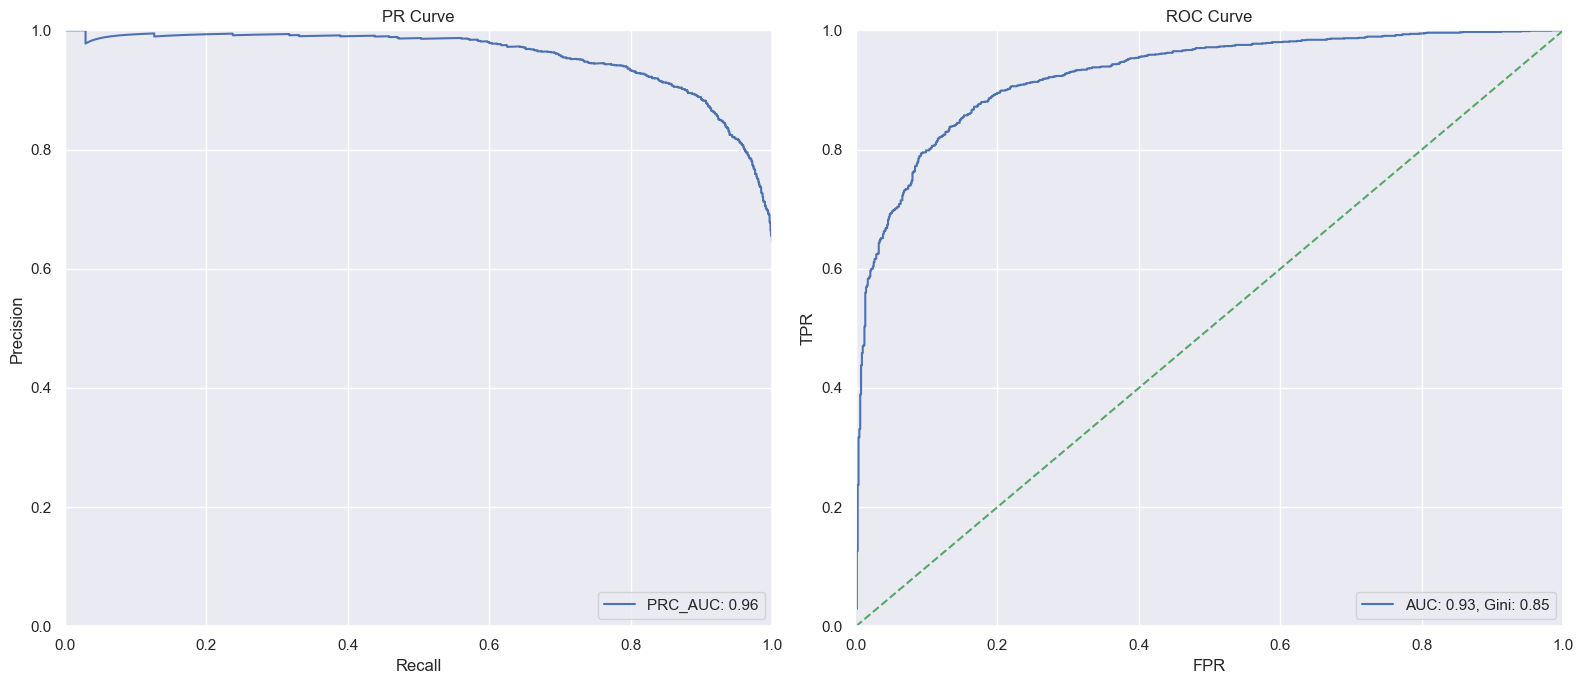

In [20]:
preds = boosting.predict_proba(X_test)[:, 1]
roc_pr_curves(y_test, preds)

Попробуем также использовать xgboost

In [21]:
import xgboost as xgb
import time

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Определение параметров для XGBClassifier с линейным бустингом
params = {
    'booster': 'gblinear',
    'num_class': 2,
    'eval_metric': 'mlogloss'
}

# Список для хранения истории обучения
evals = [(dtrain, 'train'), (dtest, 'test')]
history = {
    'train': {},
    'test': {}
}

# Запуск обучения и замер времени
start_time = time.time()
model = xgb.train(params, dtrain, num_boost_round=100, evals=evals,
                  evals_result=history, verbose_eval=False)
end_time = time.time()

# Вывод времени обучения
training_time = end_time - start_time
print(f"Время обучения: {training_time:.2f} секунд")

Время обучения: 0.41 секунд


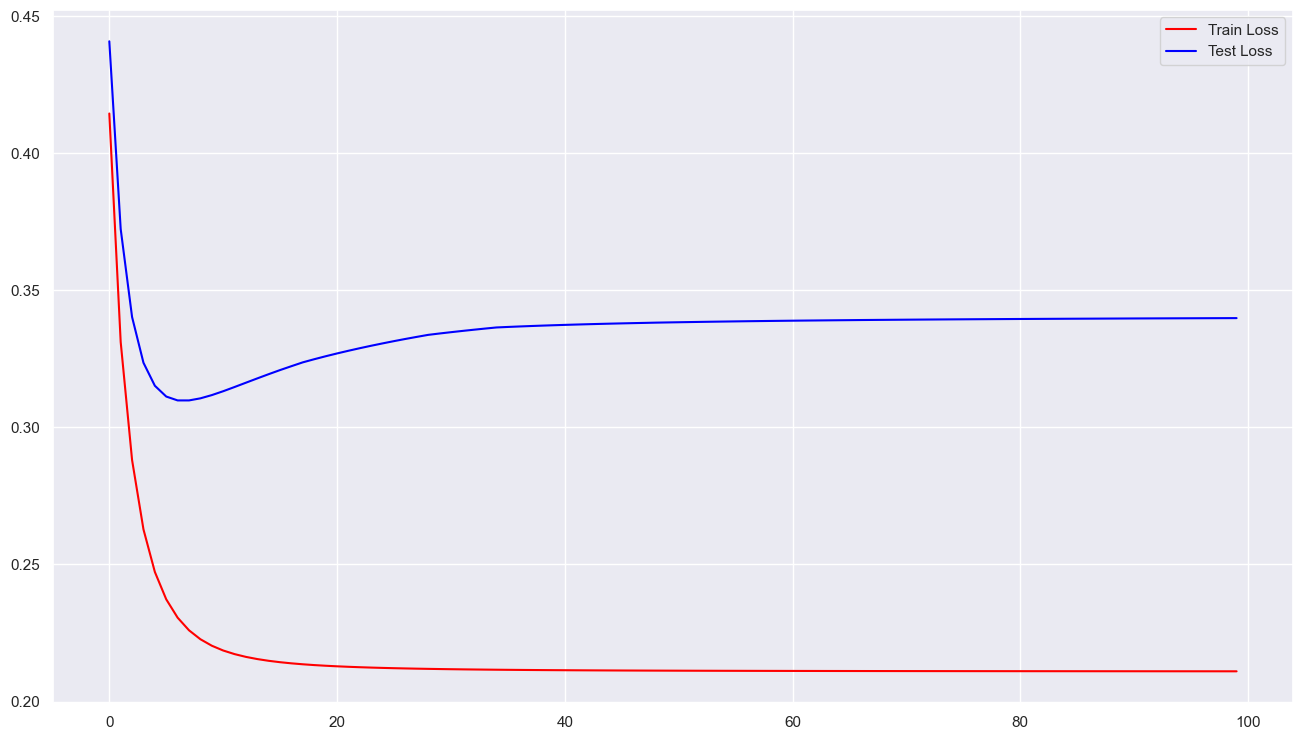

In [22]:
train_loss = history['train']['mlogloss']
test_loss = history['test']['mlogloss']

plt.figure(figsize=(16, 9))
plt.plot(range(len(train_loss)), train_loss, color='red', label='Train Loss')
plt.plot(range(len(test_loss)), test_loss, color='blue', label='Test Loss')

plt.legend();

Теперь возьмите `sklearn.linear_model.SGDClassifier` иобучите на тех же данных. Не забудьте вытащить историю функции потерь

In [23]:
from sklearn.linear_model import SGDClassifier
from collections import defaultdict
from sklearn.metrics import log_loss

clf = SGDClassifier(loss='log', max_iter=1, tol=None)
loss_history_SGD = defaultdict(list)
n_epochs = 100

start = time.time()
for epoch in range(n_epochs):
    clf.partial_fit(X_train, y_train, classes=(0, 1))   
    y_val_proba = clf.predict_proba(X_valid)
    y_train_proba = clf.predict_proba(X_train)

    train_loss = log_loss(y_train, y_train_proba)
    val_loss = log_loss(y_valid, y_val_proba)
    
    loss_history_SGD['train_loss'].append(train_loss)
    loss_history_SGD['val_loss'].append(val_loss)
end = time.time()

train_time_sgd = end - start

Покажите на одном графике изменение функции потерь для бустинга и SGD классификатора. Сравните следующие детали у бустинга и линейной модели:

- время обучения
- сходимость (как быстро, как стабильно и прочее)
- графики функции потерь на трейне и на валидации

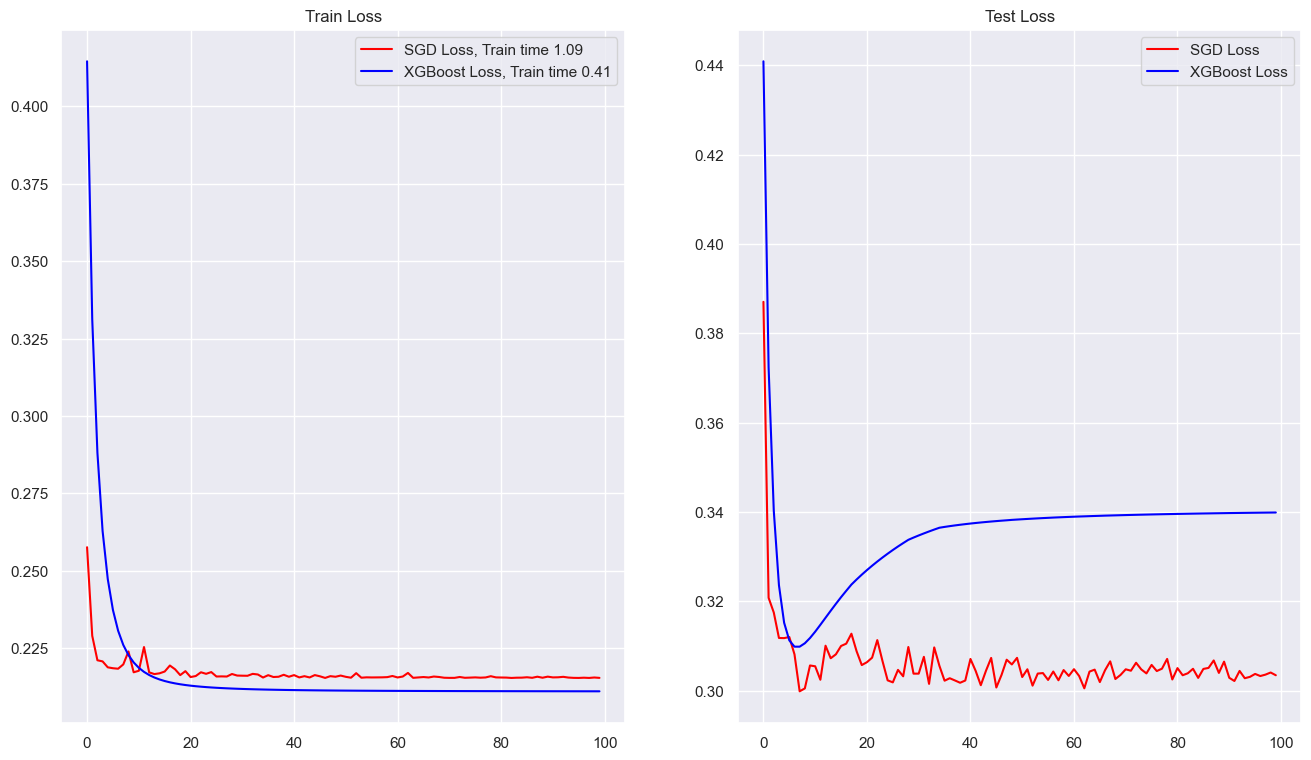

In [24]:
plt.figure(figsize=(16, 9))
    
plt.subplot(1, 2, 1)
plt.plot(range(100), loss_history_SGD['train_loss'], color='red', label=f'SGD Loss, Train time {train_time_sgd:.2f}')
plt.plot(range(100), history['train']['mlogloss'], color='blue', label=f'XGBoost Loss, Train time {training_time:.2f}')
plt.title('Train Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.plot(range(100), loss_history_SGD['val_loss'], color='red', label='SGD Loss')
plt.plot(range(100), history['test']['mlogloss'], color='blue', label='XGBoost Loss')
plt.title('Test Loss')
plt.legend(loc='upper right')

plt.show()

<font color='plum'>**Вопрос:** Какой вывод вы можете сделать?</font>

<font color='plum'> **Ответ:** 
- Время обучения: Бустинг обучается бустрее
- Сходимость: У бустинга сходмость более гладкая
- Динамика ошибок: У бустинга ошибка на валидации начинает расти уже на 5-7 итерации, в отличие от SGD, что говорит о склонности к переобучению
</font>

### 2.2. Бутстрап (0.5 балла)
Как известно, при обучении базовых алгоритмов в беггинге, используется бутстрапированная выборка. Звучит хайпово, почему бы не попробовать сделать то же самое в бустинге?

| <font color='lightblue'>XGBoost</font> | <font color='lightgreen'>LightGBM</font> | <font color='palegoldenrod'>CatBoost</font> |
| --- | --- | --- |
| `subsample`, — | `subsample`, `bagging`| `subsample`, `bootstrap_type`|

Вам нужно реализовать параметры:
- `subsample: float | int = 1.0` — доля или число объектов, на которой будет обучаться базовая модель (какую часть составляет бутстрапная выборка от исходной обучающей). Соответствует бутстрапу типа `Bernoulli`. Каждый объект либо входит в подвыборку, либо нет
- `bagging_temperature: float | int = 1.0` — веса объектов, которые попадают в выборку. Соответствует бутстрапу типа `Bayesian`. Каждый объект имеет определенный вес $t$, на который впоследствии домножается по формуле $w = (-\log(X))^t$, где $X \sim {U[0, 1]}$, после чего попадает в выборку. Таким образом можно сделать симуляцию повторений
- `bootstrap_type: str | None = 'Bernoulli'` — тип бутстрапа

<font color='plum'>**Вопрос:** как бутстрап может помочь в обучении с точки зрения смещения, разброса и вообще?</font>

<font color='plum'>**Ответ:** бутстрап позволяет снизить переобучения за счет того, что каждый раз модели обучаются на разных объектов - за счет этого падают смещение и разброс, что для бустинга - хорошо. </font>

In [42]:
%autoreload 2

from boosting import Boosting, roc_pr_curves

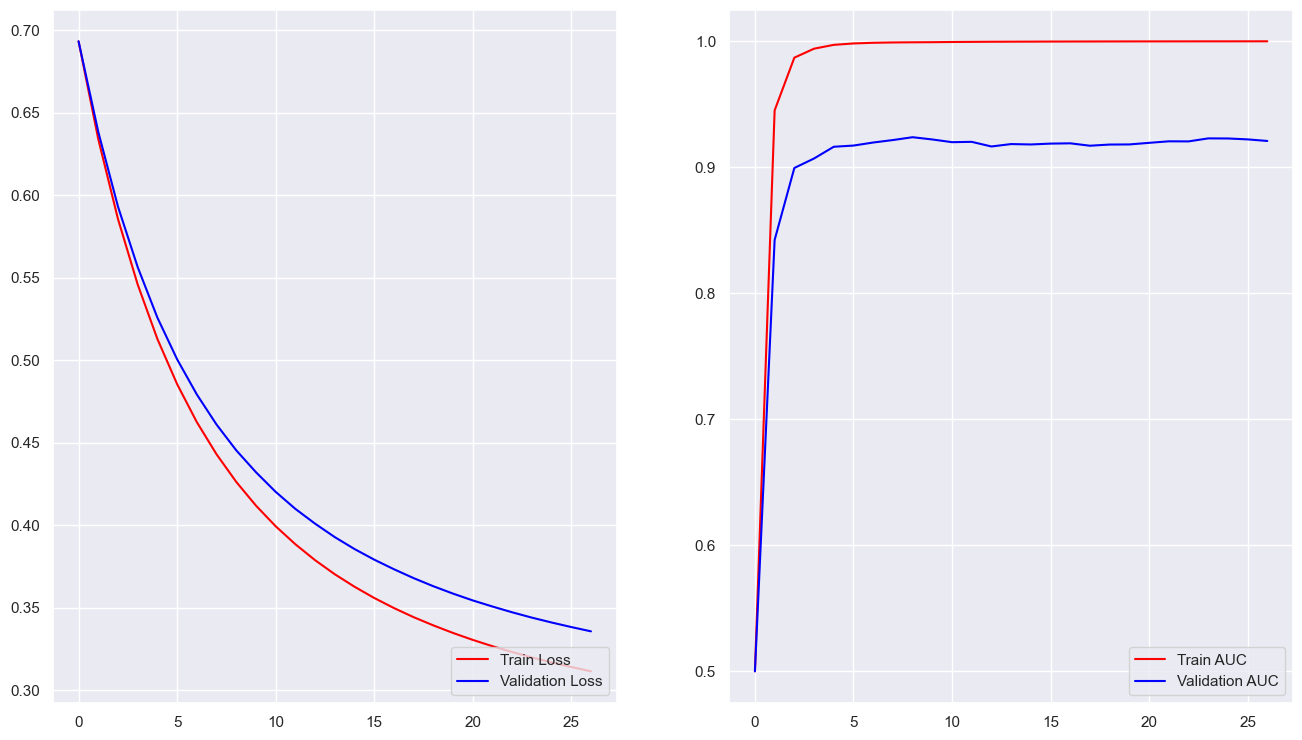

Train ROC-AUC 0.9997
Valid ROC-AUC 0.9208
Test ROC-AUC 0.9171


In [44]:
boosting = Boosting(n_estimators=500, learning_rate=0.4, early_stopping_rounds=3, bagging_temperature=2, subsample=0.6)

boosting.fit(X_train, y_train, X_valid, y_valid, plot=True, plot_process=True)

print(f'Train ROC-AUC {boosting.score(X_train, y_train):.4f}')
print(f'Valid ROC-AUC {boosting.score(X_valid, y_valid):.4f}')
print(f'Test ROC-AUC {boosting.score(X_test, y_test):.4f}')

### Бонус. GOSS (0.5 балла)

Заметим, что во время обучения не все объекты одинаково важны. Один из вариантов это исправить — ввести какие-то веса на объекты, однако можно пойти чуть хитрее. В <font color='lightgreen'>**LightGBM**</font> придумали подход [Gradient-based One-side Sampling](https://www.microsoft.com/en-us/research/wp-content/uploads/2017/11/lightgbm.pdf)

Давайте оценивать важность объектов в отдельный момент обучения нового дерева. Будем считать, какой антиградиент привносит каждый объект. Далее разобъем градиенты на 2 группы. Объекты с большими градиентами берутся все, с маленькими — только часть, по аналогии с бутстрапом, с отрицательными — выкидываются. И не забываем домножить на фактор, чтобы учесть выкинутые объекты. Подробнее в статье

| <font color='lightblue'>XGBoost</font> | <font color='lightgreen'>LightGBM</font> | <font color='palegoldenrod'>CatBoost</font> |
| --- | --- | --- |
| — | `bagging='goss'`| `bootstrap_type='MVS'`|

Параметры, которые нужно сделать:

- `goss: bool | None = False` — GOSS бустинг или нет
- `goss_k: float | int = 0.2` — доля объектов, градиенты которых будем считать большими. Все остальное — маленькими
- `subsample: float | int = 0.3` — параметры сэмплинга для маленьких градиентов из пункта 2.1

In [26]:
# *𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚

### 2.3. Работа с признаками (1 балл)

1. Помимо выбора случайных объектов, есть идея выбирать случайное подмножество признаков, заложенная в Random Forest. Мотивация это делать точно та же самая, что и в бутстрапировании, за это будет отвечать `rsm`

2. С другой стороны, вместо того, чтобы выкидывать признаки, можно попробовать проредить их множество значений, применив бинаризацию. В идеале это стоит делать с датасетом до обучения модели, но не обязательно, можно, например, на этапе `fit`, а в `partial_fit` приходит уже квантизованный датасет. Для этого существует множество алгоритмов, мы предлагаем сделать два наиболее простых:

- $\text{Uniform}$. Значения признака $[\min f_i, \max f_i]$ отображаются в `nbins` отрезков одинаковой длины, которые полностью покрывают интервал
- $\text{Quantile}$. Тот же самый отрезок сортируется и бьется на `nbins` квантилей от 0 до 1

| <font color='lightblue'>XGBoost</font> | <font color='lightgreen'>LightGBM</font> | <font color='palegoldenrod'>CatBoost</font> |
| --- | --- | --- |
| `colsample_bytree`, `tree_method` | `colsample_bytree`, `max_bin`| `rsm`, `quantize(...)`|

Нужно добавить параметры:
- `rsm: float | int = 1.0` — доля или число признаков, участвующих в обучении модели. Каждый признак либо входит, либо не входит в пул, на котором обучается базовый алгоритм, по аналогии с бутстрапом Бернулли
- `quantization_type: str | None = None` — тип квантизации, если она есть
- `nbins: int = 255` — число бинов для квантизации. Игнорируем, если тип квантизации не указан

<font color='plum'>**Вопрос**: как квантизация поможет в обработке выбросов и нанов?</font>

<font color='plum'>**Ответ**: ... </font>

<font color='plum'>**Вопрос**: можно ли просто заполнить наны каким-то числом? Имеет ли значение, что это за число (-1, -100, -1e32)?</font>

<font color='plum'>**Ответ**: ... </font>

In [80]:
%autoreload 2

from boosting import Boosting, roc_pr_curves

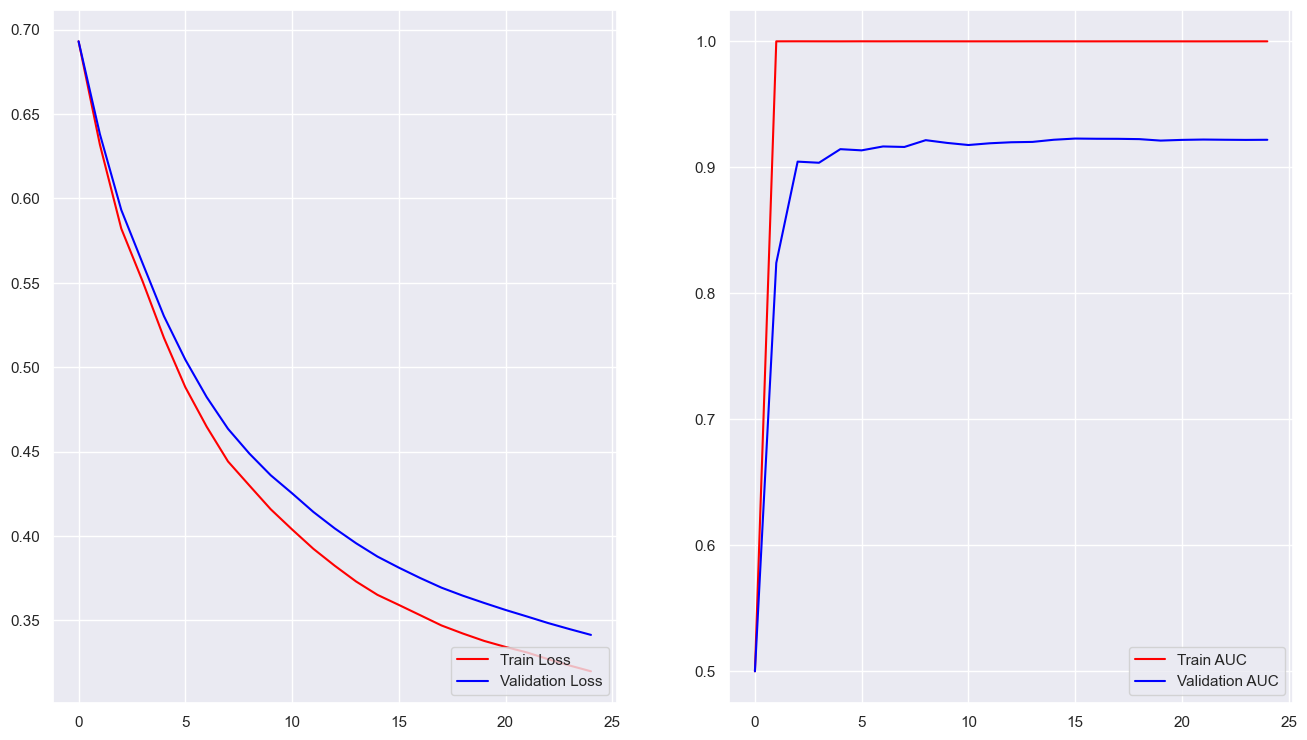

Train ROC-AUC 0.9998
Valid ROC-AUC 0.9215
Test ROC-AUC 0.9208


In [57]:
boosting = Boosting(n_estimators=25, learning_rate=0.4, early_stopping_rounds=9, rsm=0.6, quantization_type='uniform')

boosting.fit(X_train, y_train, X_valid, y_valid, plot=True, plot_process=True)

print(f'Train ROC-AUC {boosting.score(X_train, y_train):.4f}')
print(f'Valid ROC-AUC {boosting.score(X_valid, y_valid):.4f}')
print(f'Test ROC-AUC {boosting.score(X_test, y_test):.4f}')

In [59]:
# индексы фичей первых трех деревьев
boosting.features[:3]

[array([133,  84,  55, 127, 129, 164,   8, 168,  18,  72,  82,  22, 115,
         66, 109,  68,  29,  44,  69,   1,   4,  59,  76,  23, 126,  27,
        111,  30,  91,  28, 105,  31, 107,  47,  75, 155, 137, 167,  56,
        166,  26,  73, 163,  20,  62, 147, 103,  41,  33,   9, 139, 165,
         12,  54, 141,  90, 162, 101,  43,  98, 152,  80, 138,  36,  74,
         93,  50,  96,  46, 120,  97, 161,  60,  17, 158, 136, 159,  85,
         48, 108, 160, 124,  21,  13,  37, 100,  86,  39,   2,  16,  42,
          7,   0, 112,  65, 144,  34,   5, 157,  64, 153]),
 array([ 72,  83,  59,  91, 141, 136,  23, 131, 163,  10,  17, 150,  51,
          4,   1, 114,  26,  44,  57, 165, 134,  14, 133,  86, 152,  54,
         35, 103,  97,  79, 112,  90, 111,  60, 167,  81, 106, 107,  65,
        166, 138,  45, 168,  20, 130,  95,  61, 142,  62, 126, 161,  78,
         37, 146,  99,  58,  64,  75, 121, 118,  63, 125,  82, 162,  34,
        139, 128, 127,  18,  38,  98,  80,  48,  15, 157,  21,  

### Бонус. Квантизация (1.5 балл)

В текущих имплементациях бустинга используются более сложные методы квантизации. К сожалению, способы выше страдают либо от неравноправности бинов — в каких-то объектов больше, в каких-то меньше, либо от того, что целевая переменная от бинов зависит опосредованно. Предлагается это исправить следующими способами:

1. $\text{MinEntropy}$. Это [один из методов](https://catboost.ai/docs/en/concepts/quantization), который используется для бинаризации в <font color='palegoldenrod'>**CatBoost**</font>, остальные на него очень похожи. Будем жадно набирать бины так, чтобы энтропия объектов внутри ($\sum_{i \in \text{bin}} x_i\log(x_i)$) была как можно меньше. Сделать такое разбиение руками непросто, но вам эта задача должна что-то напоминать
   
2. $\text{PiecewiseEncoding}$. Это относительно свежий метод для [табличных трансформеров](https://arxiv.org/pdf/2203.05556). Суть заключается в том, что бины для квантизации будем брать не с потолка, а именно те, что нужны для разбиения таргета. (В статье делается кодирование в вектор длины $T$, где $T$ число бинов, в нашем случае это излишне, бинов можно оставить столько же, но взять лмшь закодированную по формуле часть)

| <font color='lightblue'>XGBoost</font> | <font color='lightgreen'>LightGBM</font> | <font color='palegoldenrod'>CatBoost</font> |
| --- | --- | --- |
| — | — | `feature_border_type="Piecewise"` |

Нужно добавить опцию:

- `'MinEntropy'` для `quantization_type` — какую квантизацию используем

Реализуйте оба способа подсчета (или один, но тогда балл неполный) и сравните, удалось ли улучшить качество?

### 2.4. Важность признаков (0.5 балла)

Поскольку наша базовая модель — это дерево из `sklearn`, мы можем вычислить важность признака отдельно для каждого дерева и усреднить (воспользуйтесь `feature_importances_` у `DecisionTreeRegressor`), после этого нормировать значения, чтобы они суммировались в единицу (обратите внимание, что они должны быть неотрицательными — иначе вы что-то сделали не так). Разумеется, способ не единственный, если хочется, посмотрите в документации

| <font color='lightblue'>XGBoost</font> | <font color='lightgreen'>LightGBM</font> | <font color='palegoldenrod'>CatBoost</font> |
| --- | --- | --- |
| `model.get_score()` | `lightgbm.importance()` | `model.get_feature_importance()` |

Допишите к бустингу:
- `feature_importances_` — атрибут, который возвращает важность признаков, согласно методу выше

In [81]:
boosting = Boosting(n_estimators=25, learning_rate=0.4)

boosting.fit(X_train, y_train, X_valid, y_valid)

print(f'Train ROC-AUC {boosting.score(X_train, y_train):.4f}')
print(f'Valid ROC-AUC {boosting.score(X_valid, y_valid):.4f}')
print(f'Test ROC-AUC {boosting.score(X_test, y_test):.4f}')

Train ROC-AUC 0.9998
Valid ROC-AUC 0.9084
Test ROC-AUC 0.9048


Покажите, какие признаки оказались самыми важными

In [93]:
features = [i for i in range(X_train.shape[1])]
feature_imp = pd.DataFrame(data = {'feature': features,'imp': boosting.feature_importances_})
feature_imp.sort_values(by='imp', ascending=False)

,feature,imp
166,166,9.997691e-01
164,164,7.496811e-05
168,168,1.893378e-06
165,165,1.889497e-06
36,36,1.258957e-06
...,...,...
26,26,8.920946e-07
58,58,8.920946e-07
98,98,8.920946e-07
49,49,8.920946e-07


### Бонус. DART (1.5 балла)

Ранее мы обсуждали, что каждый базовый алгоритм пытается исправить ошибки всего предыдущего ансамбля. Из-за этого возникает неравноправие — каждая новая модель вносит все меньший и меньший вклад. Уверенные обучатели нейросетей знают, что это может привести к переобучению. Но выход есть, и выход этот [DART](https://arxiv.org/pdf/1505.01866)!

В DL есть такой вид регуляризации, как dropout, когда некоторые узлы нейросети со случайным шансом отключаются. Можно попробовать обобщить этот подход на случай бустингов и случайно выкидывать деревья из композиции во время обучения

1. Выбираем, какие деревья убрать. При подсчете антиградиента берем не весь ансамбль, а только ту часть, что осталась
2. Домножаем выходы дерева на $1/k$, где $k$ — число удаленных деревьев, чтобы учесть тот факт, что ансамбль был не весь. Тогда вклад отдельного дерева будет не настолько большим
3. Домножаем выходы выкинутых деревьев на $k/(k+1)$, чтобы масштабы выходов примерно совпадали

| <font color='lightblue'>XGBoost</font> | <font color='lightgreen'>LightGBM</font> | <font color='palegoldenrod'>CatBoost</font> |
| --- | --- | --- |
| `XGBClassifier(booster="dart")` | `LGBMClassifier(boosting_type="dart")` | — |

Параметры, которые нужно добавить:

- `dart: bool | None = False` — DART бустинг или нет
- `dropout_rate: int | float = 0.05` — доля деревьев, которую выкидываем во время обучения DART

In [ ]:
# *𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚

------

## Задание 3. Оптимизация (3.5 балла + 0.5 бонус)

Теперь давайте подумаем, как же правильно применять бустинги. Нас интересует: какие бустинги вообще бывают, как их правильно тюнить, и как интерпретировать

Оптимизация моделей с большим числом гиперпараметров это сложное дело. Нетрудно догадаться, что в случае, когда параметров $m$, сложность перебора в самом худшем случае будет порядка $n^m$. У бустингов, хотя на самом деле не только, эта проблема стоит особенно остро. Подумаем, как это делать умнее

### 3.1. Знакомство с optuna (1 балл)

Для эффективного подбора гиперпараметров существует несколько решений, основанных на байесовской оптимизации. В этом задании предлагается познакомиться с библиотекой [optuna](https://optuna.org/), которая делает перебор гиперпараметров легким и приятным, а также сохраняет всю историю экспериментов в одно место за вас

Подберите на валидации оптимальные значения следующих гиперпараметров для вашей реализации бустинга:
- `max_depth`
- `n_estimators`
- `learning_rate`
- любые другие параметры, которые вам понравились

Заметим, что оптуна это крайне гибкая библиотека, в которой можно реализовать абсолютно любую логику, которую пожелаете. За вас там есть лишь выбор модели. Чтобы не плодить несколько `objective`, можно слегка менять тело функции, например, добавить опциональные параметры, но шаблоном пользоваться не обязательно, как обычно

Подберите диапазон параметров самостоятельно, не забывайте фиксировать сид (нет, его не нужно перебирать). Сохраните и покажите оптимальный набор параметров. Сравните графики функций потерь для оптимального и дефолтного бустингов. Покажите, какие параметры дали наибольший прирост (для этого придется почитать документацию оптуны)

In [104]:
import optuna
from sklearn.metrics import roc_auc_score

In [122]:
def objective(trial):
    
    params = {'max_depth': trial.suggest_int('max_depth', 1, 15, 2)}
    
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-4, 1)
    
    evals={}

    model = Boosting(base_model_params=params, n_estimators=n_estimators, learning_rate=learning_rate)
    model.fit(X_train, y_train)

    val_preds = model.predict_proba(X_valid)[:, 1]

    sigmoid = lambda x: 1 / (1 + np.exp(-x))
    loss = -np.log(sigmoid(y_valid * val_preds)).mean()
    
    return loss
    
study = optuna.create_study(directions = ['minimize'])
 
study.optimize(objective, n_trials=3)

[I 2024-12-22 12:03:39,223] A new study created in memory with name: no-name-4db089c7-d0fa-4fef-806f-51dede7fa8df
[I 2024-12-22 12:04:00,101] Trial 0 finished with value: 0.4581750340428904 and parameters: {'max_depth': 7, 'n_estimators': 201, 'learning_rate': 0.09828221716745207}. Best is trial 0 with value: 0.4581750340428904.
[I 2024-12-22 12:04:09,360] Trial 1 finished with value: 0.5492861164555807 and parameters: {'max_depth': 7, 'n_estimators': 84, 'learning_rate': 0.00020181280716698814}. Best is trial 0 with value: 0.4581750340428904.
[I 2024-12-22 12:04:28,301] Trial 2 finished with value: 0.47051049533709155 and parameters: {'max_depth': 1, 'n_estimators': 374, 'learning_rate': 0.02680734200985244}. Best is trial 0 with value: 0.4581750340428904.


In [132]:
study.trials[0].value

0.4581750340428904

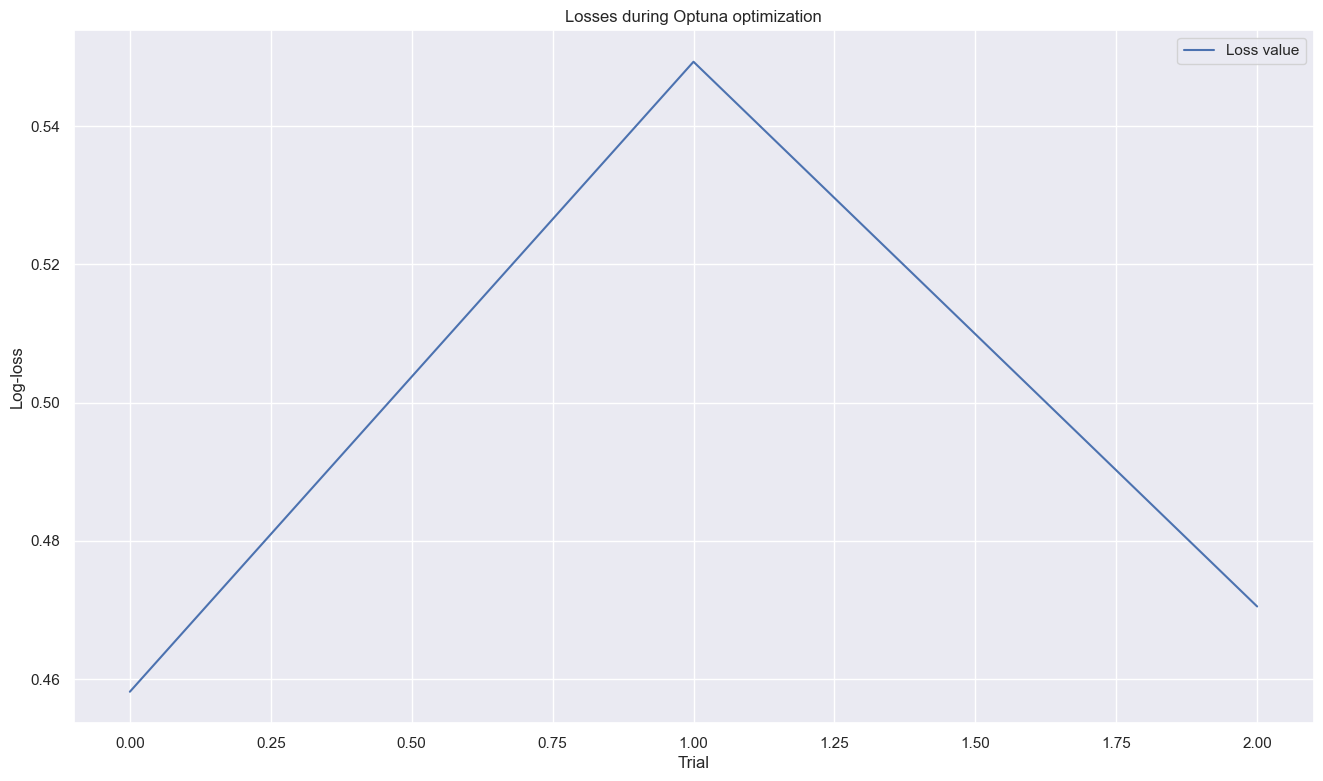

In [136]:
# Динамика значений функции потреь
trials_info = study.trials
Loss_values = [trial.value for trial in trials_info]

plt.figure(figsize=(16, 9))
plt.plot(Loss_values, label='Loss value')
plt.xlabel('Trial')
plt.ylabel('Log-loss')
plt.title('Losses during Optuna optimization')
plt.legend()
plt.show()

In [139]:
tree_params = study.trials_dataframe()
tree_params.sort_values(by = 'value')

,number,value,datetime_start,datetime_complete,duration,params_learning_rate,params_max_depth,params_n_estimators,state
0,0,0.458175,2024-12-22 12:03:39.224814,2024-12-22 12:04:00.101890,0 days 00:00:20.877076,0.098282,7,201,COMPLETE
2,2,0.470510,2024-12-22 12:04:09.362020,2024-12-22 12:04:28.301074,0 days 00:00:18.939054,0.026807,1,374,COMPLETE
1,1,0.549286,2024-12-22 12:04:00.103000,2024-12-22 12:04:09.360014,0 days 00:00:09.257014,0.000202,7,84,COMPLETE


In [141]:
study.trials[0].params

{'max_depth': 7, 'n_estimators': 201, 'learning_rate': 0.09828221716745207}

In [ ]:
# ОПТИМАЛЬНЫЙ

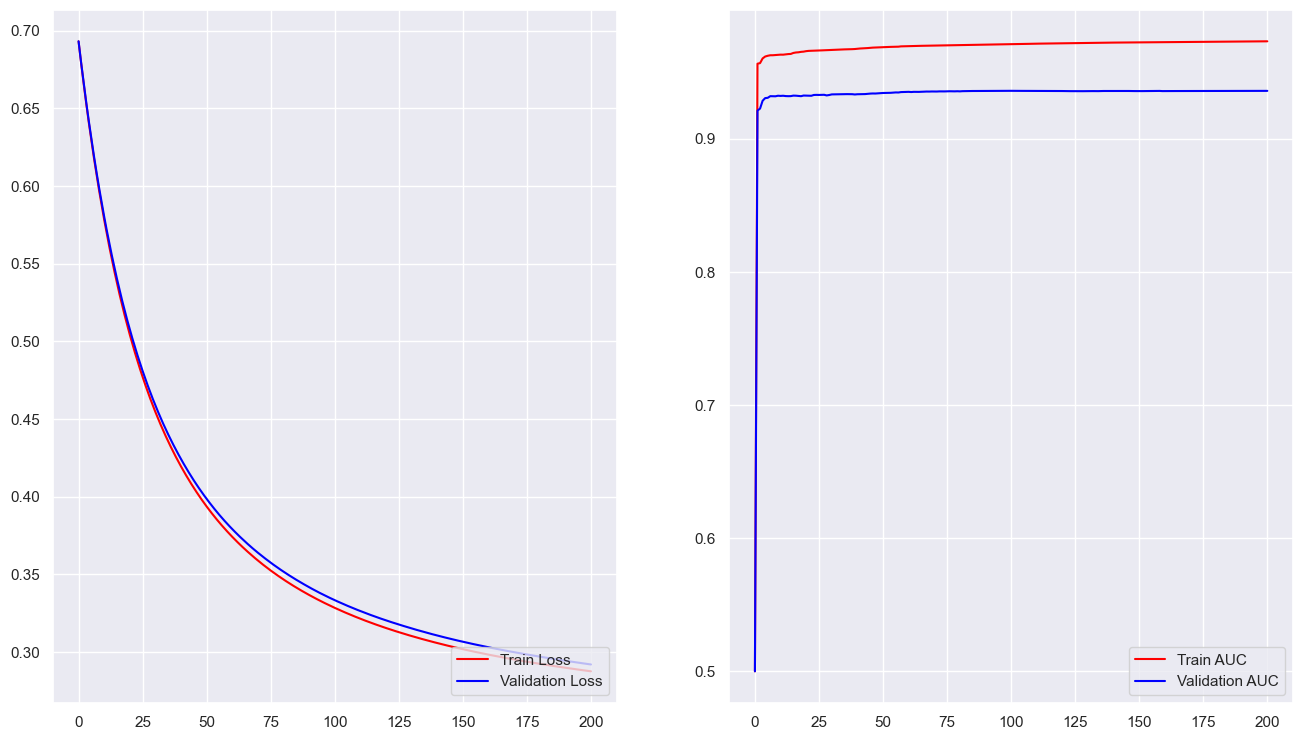

Time taken: 20.762686014175415
Train ROC-AUC 0.9732
Valid ROC-AUC 0.9360
Test ROC-AUC 0.9319


In [190]:
params = {
    'max_depth': 7,
}
boosting = Boosting(base_model_params=params, n_estimators=201, learning_rate=0.09828221716745207)

start = time.time()
boosting.fit(X_train, y_train, X_valid, y_valid, plot=True)
end = time.time()

print(f'Time taken: {end - start}')
print(f'Train ROC-AUC {boosting.score(X_train, y_train):.4f}')
print(f'Valid ROC-AUC {boosting.score(X_valid, y_valid):.4f}')
print(f'Test ROC-AUC {boosting.score(X_test, y_test):.4f}')

In [ ]:
# ДЕФОЛТНЫЙ

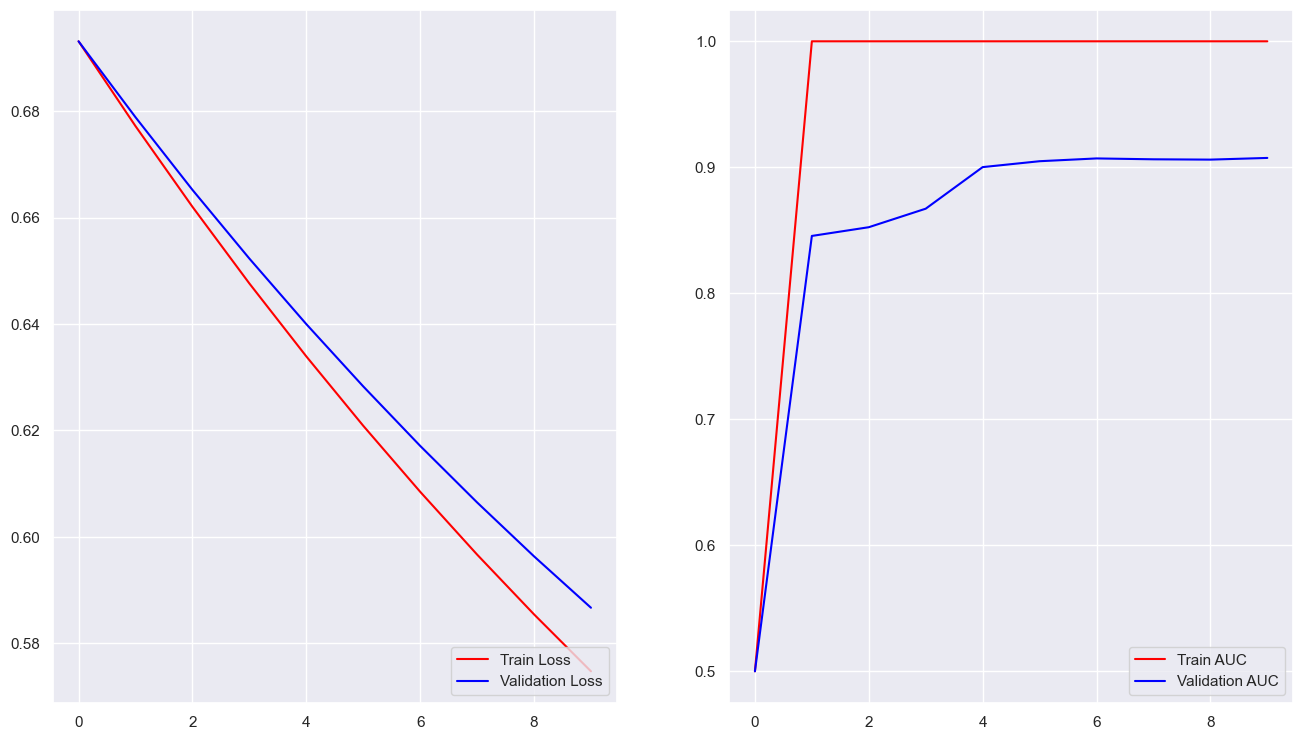

Train ROC-AUC 0.9998
Valid ROC-AUC 0.8995
Test ROC-AUC 0.8975


In [143]:
boosting = Boosting()

boosting.fit(X_train, y_train, X_valid, y_valid, plot=True)

print(f'Train ROC-AUC {boosting.score(X_train, y_train):.4f}')
print(f'Valid ROC-AUC {boosting.score(X_valid, y_valid):.4f}')
print(f'Test ROC-AUC {boosting.score(X_test, y_test):.4f}')

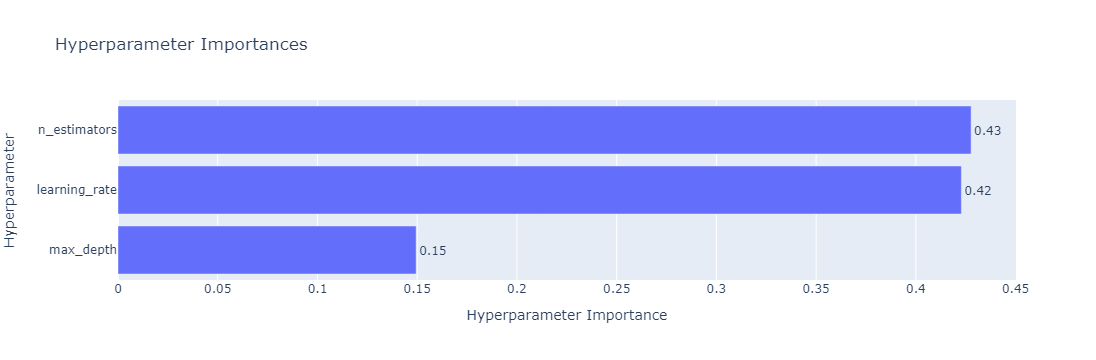

In [135]:
# Важность параметров
import optuna.visualization as vis
vis.plot_param_importances(study)

### 3.2. Глубокая оптимизация (1 балл)

Помимо эффективного перебора гиперпараметров, `optuna` предлагает более тонкий контроль над самой процедурой обучения. Улучшите процедуру оптимизации следующим образом:

1. Посмотрите, как в `optuna` устроена запись в хранилища, и добавьте это в пайплайн оптимизации. Без указания БД все запуски оптуны сотрутся, как только закончится сессия. Более того, так можно распараллелить процесс оптимизации на несколько машин
2. Посмотрите, как можно контролировать процесс обучения бустинга при помощи прунера. У библиотечных имплементаций есть уже готовые, их можно использовать пунктом ниже. Для кастомной модели возьмите что-то из `optuna.pruners`. Идея прунера — не обучать бустинг до конца, если по истории видно, что другие бустинги на этом этапе статистически лучше.
3. Добавьте сохранение истории функции потерь и времени обучения в качестве `user_attribute` сразу в `study`. Мы не хотим оптимизировать их напрямую, но они нам понадобится для сравнения моделей в дальнейшем

Добавьте хранилище и юзер атрибуты и посмотрите, ускорилась ли оптимизация с добавлением прунера

In [154]:
import time
from optuna.pruners import HyperbandPruner

def objective(trial):

    params = {
        'max_depth': trial.suggest_int('max_depth', 1, 15, 2),

    }
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-4, 1)

    start = time.time()
    model = Boosting(base_model_params=params, n_estimators=n_estimators,  learning_rate=learning_rate)
    model.fit(X_train, y_train)
    end = time.time()

    train_time = end - start

    val_preds = model.predict_proba(X_valid)[:, 1]
    sigmoid = lambda x: 1 / (1 + np.exp(-x))
    loss = -np.log(sigmoid(y_valid * val_preds)).mean()

    trial.set_user_attr('train_time', train_time)
    trial.set_user_attr('train_loss_history', model.history['train_loss'])

    return loss

storage = 'sqlite:///example.db'
study = optuna.create_study(study_name='boost', direction='minimize', storage=storage, load_if_exists=False, pruner=HyperbandPruner())
study.optimize(objective, n_trials=5) 

print('Лучшие гиперпараметры:', study.best_params)
print('Лучшее значение loss:', study.best_value)

[I 2024-12-22 13:16:34,806] A new study created in RDB with name: boost
[I 2024-12-22 13:18:43,504] Trial 0 finished with value: 0.5461176158266386 and parameters: {'max_depth': 13, 'n_estimators': 487, 'learning_rate': 0.0002779493009639613}. Best is trial 0 with value: 0.5461176158266386.
[I 2024-12-22 13:19:40,681] Trial 1 finished with value: 0.5425929463286765 and parameters: {'max_depth': 9, 'n_estimators': 343, 'learning_rate': 0.0008037662178753927}. Best is trial 1 with value: 0.5425929463286765.
[I 2024-12-22 13:20:06,212] Trial 2 finished with value: 0.4454860830492632 and parameters: {'max_depth': 1, 'n_estimators': 464, 'learning_rate': 0.5980959478856747}. Best is trial 2 with value: 0.4454860830492632.
[I 2024-12-22 13:20:30,913] Trial 3 finished with value: 0.5246585946511158 and parameters: {'max_depth': 3, 'n_estimators': 376, 'learning_rate': 0.003117527859211546}. Best is trial 2 with value: 0.4454860830492632.
[I 2024-12-22 13:20:50,558] Trial 4 finished with value

Лучшие гиперпараметры: {'max_depth': 1, 'n_estimators': 464, 'learning_rate': 0.5980959478856747}
Лучшее значение loss: 0.4454860830492632


In [155]:
study.trials_dataframe()

,number,value,datetime_start,datetime_complete,duration,params_learning_rate,params_max_depth,params_n_estimators,user_attrs_train_loss_history,user_attrs_train_time,state
0,0,0.546118,2024-12-22 13:16:34.815197,2024-12-22 13:18:43.484323,0 days 00:02:08.669126,0.000278,13,487,"[0.6931471805599453, 0.6931047281692105, 0.693...",128.319021,COMPLETE
1,1,0.542593,2024-12-22 13:18:43.513324,2024-12-22 13:19:40.665416,0 days 00:00:57.152092,0.000804,9,343,"[0.6931471805599453, 0.6930289422481675, 0.692...",56.903347,COMPLETE
2,2,0.445486,2024-12-22 13:19:40.690914,2024-12-22 13:20:06.194569,0 days 00:00:25.503655,0.598096,1,464,"[0.6931471805599453, 0.6210302822866463, 0.566...",25.224960,COMPLETE
3,3,0.524659,2024-12-22 13:20:06.224567,2024-12-22 13:20:30.896541,0 days 00:00:24.671974,0.003118,3,376,"[0.6931471805599453, 0.6927208779831532, 0.692...",24.441148,COMPLETE
4,4,0.493699,2024-12-22 13:20:30.922906,2024-12-22 13:20:50.543287,0 days 00:00:19.620381,0.047496,13,76,"[0.6931471805599453, 0.6859342626481683, 0.678...",19.501073,COMPLETE


### 3.3. Готовые реализации (1 балл)

Библиотек для бустингов существует много, но активно используются лишь три. Ваша задача — попробовать их в деле, посмотреть на их уникальные фишки и понять, что вам нравится больше всего

Возьмите любую из популярных библиотек: <font color='lightblue'>`xgboost`</font>, <font color='lightgreen'>`lightgbm`</font>, <font color='palegoldenrod'>`catboost`</font>.
Ваша задача — взять одну из них, подобрать те же оптимальные параметры, что и выше, плюс что-то, что вам понравилось в них больше всего (может быть абсолютно любая фишка из пунктов выше или что-то, что вы найдете сами, не обязательно эксклюзивное), и сравнить две оптимизированные модели по
- динамике функции потерь (на обучающей и на валидационной выборке)
- времени обучения

In [112]:
import lightgbm as lgbm

Сразу поберем гиперпараметры. Поскольку модель склонна к переобучению - будем минимизировать overfitting в том числе.

In [160]:
def objective(trial):

    train_dataset = lgbm.Dataset(X_train, label = y_train) 
    test_dataset = lgbm.Dataset(X_test, label = y_test)
    
    params = {
        'objective' : 'binary',
        'n_estimators': 5000,
        'metric' : 'auc',
        'n_jobs' : 12,
        'early_stopping_rounds': 100,
        'random_seed' : 42,
        'verbosity' : -1,
 
        'max_bin': trial.suggest_int('max_bin', 10, 500, 10),
        'min_data_in_bin': trial.suggest_int('min_data_in_bin', 1, 20, 1),
 
        'num_leaves': trial.suggest_int('num_leaves', 2, 50, 2),
        'max_depth': trial.suggest_int('max_depth', -1, 25, 2),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 0, 200, 10),
 
        'learning_rate' : trial.suggest_float('learning_rate', 0.01, 0.1, step = 0.01),
 
        'lambda_l2' : trial.suggest_int('lambda_l2', 0, 10, 1),
        'lambda_l1' : trial.suggest_int('lambda_l1', 0, 10, 1),
        'min_gain_to_split' : trial.suggest_int('min_gain_to_split', 0, 50, 1),
 
        'feature_fraction' : trial.suggest_float('feature_fraction', 0.4, 1, step = 0.1),
        'bagging_fraction' : trial.suggest_float('bagging_fraction', 0.4, 1, step = 0.1),
        'bagging_freq' : trial.suggest_int('bagging_freq', 1, 20, 1)
    }
 
    
    evals={}
    
    model = lgbm.train(params, train_dataset, valid_sets = [train_dataset, test_dataset], callbacks = [lgbm.record_evaluation(evals)])

    auc_score_train = roc_auc_score(y_train, model.predict(X_train))
    auc_score_test = roc_auc_score(y_test, model.predict(X_test))
 
    overfitting = ((auc_score_train - auc_score_test)/auc_score_train)*100 # процент разницы метрики на трейне и тесте 

    sigmoid = lambda x: 1 / (1 + np.exp(-x))
    val_preds = model.predict(X_valid)
    loss_val = -np.log(sigmoid(y_valid * val_preds)).mean()

    train_preds = model.predict(X_train)
    loss_train = -np.log(sigmoid(y_train * train_preds)).mean()

    trial.set_user_attr('loss_val', loss_val)
    trial.set_user_attr('loss_train', loss_train)
    
    return overfitting, auc_score_test
    
study_2 = optuna.create_study(directions = ['minimize', 'maximize'])
 
study_2.optimize(objective, n_trials = 25)

[I 2024-12-22 13:31:21,899] A new study created in memory with name: no-name-7451d7f0-9c10-4d17-8cbc-7430460d7174
[I 2024-12-22 13:31:22,410] Trial 0 finished with values: [2.3405606081433454, 0.9306303660865692] and parameters: {'max_bin': 330, 'min_data_in_bin': 2, 'num_leaves': 40, 'max_depth': 19, 'min_data_in_leaf': 20, 'learning_rate': 0.08, 'lambda_l2': 6, 'lambda_l1': 10, 'min_gain_to_split': 34, 'feature_fraction': 0.9, 'bagging_fraction': 0.4, 'bagging_freq': 13}.
[I 2024-12-22 13:31:23,804] Trial 1 finished with values: [2.8918237588767615, 0.9365918097754292] and parameters: {'max_bin': 210, 'min_data_in_bin': 12, 'num_leaves': 12, 'max_depth': 25, 'min_data_in_leaf': 200, 'learning_rate': 0.03, 'lambda_l2': 7, 'lambda_l1': 3, 'min_gain_to_split': 6, 'feature_fraction': 0.7000000000000001, 'bagging_fraction': 0.4, 'bagging_freq': 17}.
[I 2024-12-22 13:31:24,703] Trial 2 finished with values: [2.822202516360881, 0.9327535768662134] and parameters: {'max_bin': 150, 'min_data_

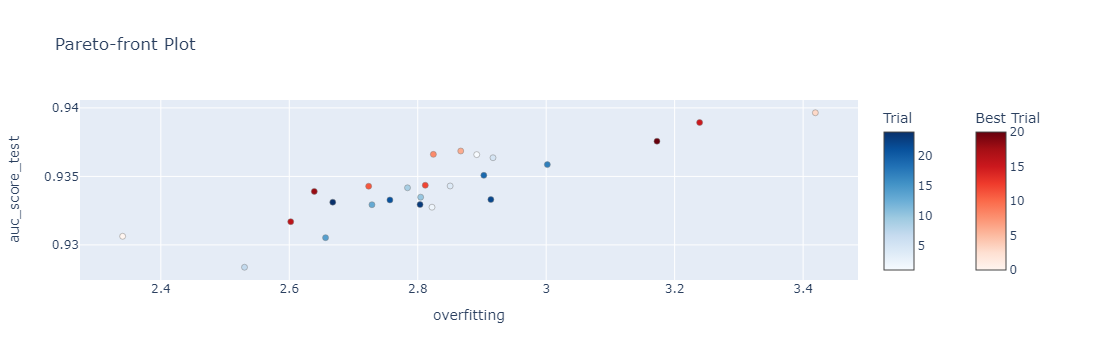

In [162]:
fig = optuna.visualization.plot_pareto_front(study_2, 
                                             targets=lambda t: (t.values[0], t.values[1]),
                                             target_names=['overfitting', 'auc_score_test'])
fig.show()

In [164]:
tree_params_2 = study_2.trials_dataframe()
tree_params_2.head()

tree_params_2[(tree_params_2['values_0'] < 3) & (tree_params_2['values_1'] >= 0.935)].sort_values(by = 'values_1', ascending = False)

,number,values_0,values_1,datetime_start,datetime_complete,duration,params_bagging_fraction,params_bagging_freq,params_feature_fraction,params_lambda_l1,...,params_max_bin,params_max_depth,params_min_data_in_bin,params_min_data_in_leaf,params_min_gain_to_split,params_num_leaves,user_attrs_loss_train,user_attrs_loss_val,system_attrs_nsga2:generation,state
6,6,2.866950,0.936856,2024-12-22 13:31:30.560311,2024-12-22 13:31:31.469310,0 days 00:00:00.908999,0.9,8,0.9,10,...,40,19,15,190,17,14,0.472051,0.474741,0,COMPLETE
8,8,2.824330,0.936611,2024-12-22 13:31:32.220310,2024-12-22 13:31:40.035306,0 days 00:00:07.814996,0.7,1,0.7,3,...,500,1,19,60,21,20,0.472226,0.474737,0,COMPLETE
1,1,2.891824,0.936592,2024-12-22 13:31:22.411315,2024-12-22 13:31:23.804313,0 days 00:00:01.392998,0.4,17,0.7,3,...,210,25,12,200,6,12,0.471321,0.474465,0,COMPLETE
5,5,2.917198,0.936364,2024-12-22 13:31:29.478312,2024-12-22 13:31:30.558311,0 days 00:00:01.079999,0.8,17,0.6,5,...,400,7,19,80,19,24,0.472348,0.475207,0,COMPLETE
19,19,2.902896,0.935079,2024-12-22 13:31:58.064297,2024-12-22 13:31:59.383295,0 days 00:00:01.318998,0.9,9,0.5,5,...,490,5,7,40,28,46,0.472968,0.475740,0,COMPLETE


In [166]:
optuna_params = study_2.trials[6].params
optuna_params

{'max_bin': 40,
 'min_data_in_bin': 15,
 'num_leaves': 14,
 'max_depth': 19,
 'min_data_in_leaf': 190,
 'learning_rate': 0.08,
 'lambda_l2': 7,
 'lambda_l1': 10,
 'min_gain_to_split': 17,
 'feature_fraction': 0.9,
 'bagging_fraction': 0.9,
 'bagging_freq': 8}

In [191]:
def model_learn_now(X_train, y_train, X_test, y_test):

    params = {'max_bin': 40,
             'min_data_in_bin': 15,
             'num_leaves': 14,
             'max_depth': 19,
             'min_data_in_leaf': 190,
             'learning_rate': 0.08,
             'lambda_l2': 7,
             'lambda_l1': 10,
             'min_gain_to_split': 17,
             'feature_fraction': 0.9,
             'bagging_fraction': 0.9,
             'bagging_freq': 8, 
             'verbosity' : -1,
             'metric': ['auc', 'binary_logloss']}
    
    evals={}

    #трейн и тест
    train_dataset = lgbm.Dataset(X_train, label = y_train) 
    test_dataset = lgbm.Dataset(X_test, label = y_test)
    #обучение
    start = time.time()
    print('start train')
    model = lgbm.train(params, train_dataset, valid_sets = [train_dataset, test_dataset], callbacks = [lgbm.record_evaluation(evals)])
    end = time.time()
    print(f'End train. Time taken: {end - start}')

    #предсказание
    print('pred moment')
    pred_train = model.predict(X_train)
    pred_val = model.predict(X_test)
    
    return pred_train, pred_val, model, evals


def plot_loss_and_metric(evals):

    #Извлечение данных о потерях и метриках из evals
    train_auc = evals['training']['auc']
    test_auc = evals['valid_1']['auc']
    train_loss = evals['training']['binary_logloss']
    test_loss = evals['valid_1']['binary_logloss']
    epochs = range(len(train_loss))

    plt.figure(figsize=(16, 9))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, label='Train Loss')
    plt.plot(epochs, test_loss, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Binary Logloss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_auc, label='Train AUC')
    plt.plot(epochs, test_auc, label='Test AUC')
    plt.xlabel('Epoch')
    plt.ylabel('AUC')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [188]:
pred_train, pred_val, model, evals = model_learn_now(X_train, y_train, X_test, y_test)

start train
End train. Time taken: 0.24492597579956055
pred moment


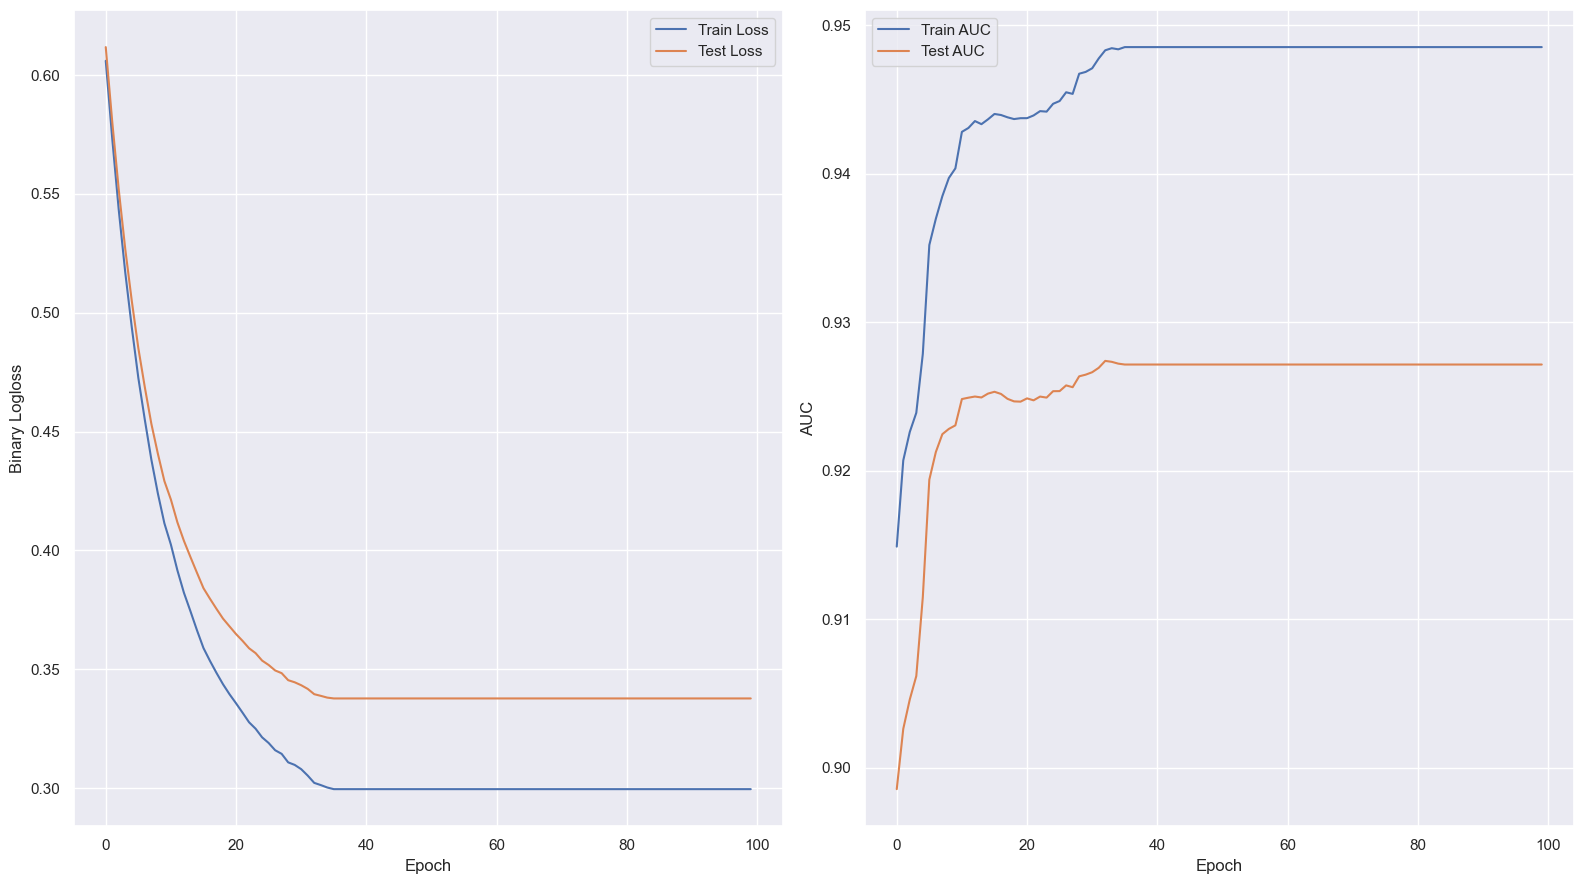

In [192]:
# lightgbm results
plot_loss_and_metric(evals)

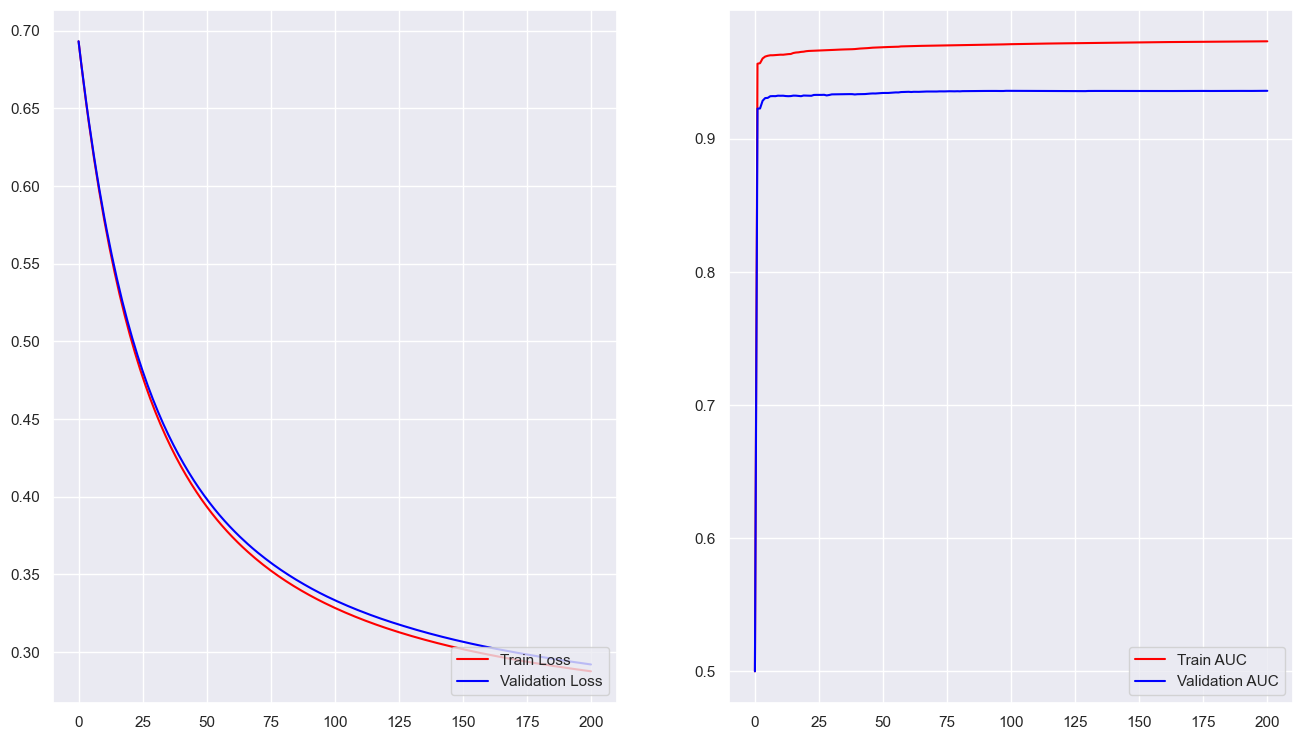

Time taken: 20.48309302330017


In [193]:
#Повтороно обучим кастомный бустинг, чтобы сравнить результаты 

params = {
    'max_depth': 7,
}
boosting = Boosting(base_model_params=params, n_estimators=201, learning_rate=0.09828221716745207)

start = time.time()
boosting.fit(X_train, y_train, X_valid, y_valid, plot=True)
end = time.time()

print(f'Time taken: {end - start}')

Заметим, что поведение похожее, но наш бустинг учится значительно дольше

<font color='plum'>**Вопрос:** Какая архитектура вам нравится больше всего и почему?</font>

<font color='plum'>**Ответ**: ~~Его используют все коллеги~~ Официальные причины. Во-первых, он обладает высокой скоростью и производительностью благодаря использованию метода "Histogram-based", что значительно ускоряет обучение по сравнению с XGBoost и CatBoost. Во-вторых, LightGBM эффективно использует память и оптимизирован для работы с большими наборами данных, что позволяет избежать проблем с производительностью. В-третьих, библиотека поддерживает категориальные признаки без необходимости предварительной обработки, что упрощает подготовку данных. Кроме того, LightGBM предлагает множество параметров для настройки, что позволяет оптимизировать модель под конкретные задачи. Наконец, он часто используется в соревнованиях по машинному обучению </font>

### Бонус. Random Forest (0.5 балла)

Если очень захотеть, оптуна может оптимизировать все, что угодно, даже нейросети. Давайте противопоставим бустингу его злейшего врага — алгоритм Random Forest.

Возьмите реализацию случайного леса из <font color='lightgreen'>`lightgbm`</font>. Посмотрите, какие там есть гиперпараметры, переберите что-либо из них вместе с `max_depth` и `n_estimators`.

Сравните его качество и динамику функции потерь (на обучающей и на валидационной выборке) с таковыми у бустинга и сделайте вывод, а нужен ли Random Forest?

In [ ]:
# *𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚

### 3.4. Бустинг и вероятности (0.5 балла)

С качеством мы более-менее разобрались, но что насчет вероятностей? Постройте калибровочную кривую для вашей лучшей модели бустинга. Насколько хорошо бустинг оценивает вероятности?

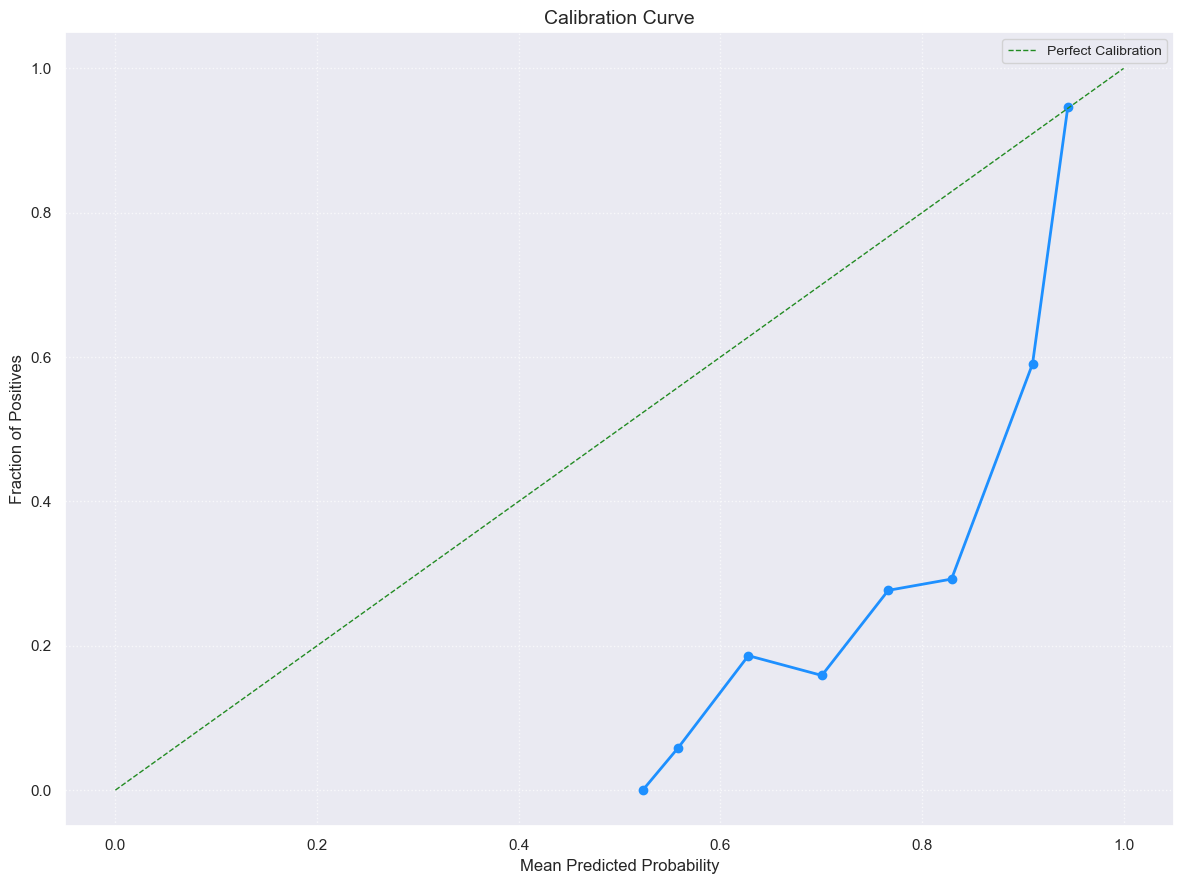

In [203]:
from sklearn.calibration import calibration_curve
#from sklearn.metrics import brier_score_loss

boosting_preds = boosting.predict_proba(X_test)[:, 1]

boosting_trues, boosting_preds = calibration_curve(y_test, boosting_preds, n_bins=15)

#brier_score = brier_score_loss(y_test, boosting_preds)

plt.figure(figsize=(12, 9))  
plt.plot(boosting_preds, boosting_trues, color='dodgerblue', marker='o', linestyle='-', linewidth=2, markersize=6)
plt.plot([0, 1], [0, 1], label='Perfect Calibration', linestyle='--', color='forestgreen', linewidth=1)
plt.xlabel('Mean Predicted Probability', fontsize=12) 
plt.ylabel('Fraction of Positives', fontsize=12)
plt.title('Calibration Curve', fontsize=14) 
plt.grid(True, linestyle=':', alpha=0.7)  
plt.legend(fontsize=10) 
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05) 
plt.tight_layout()
plt.show()


Постройте также калибровочную кривую для логистической регрессии, сравните их между собой. Проанализируйте полученные результаты.

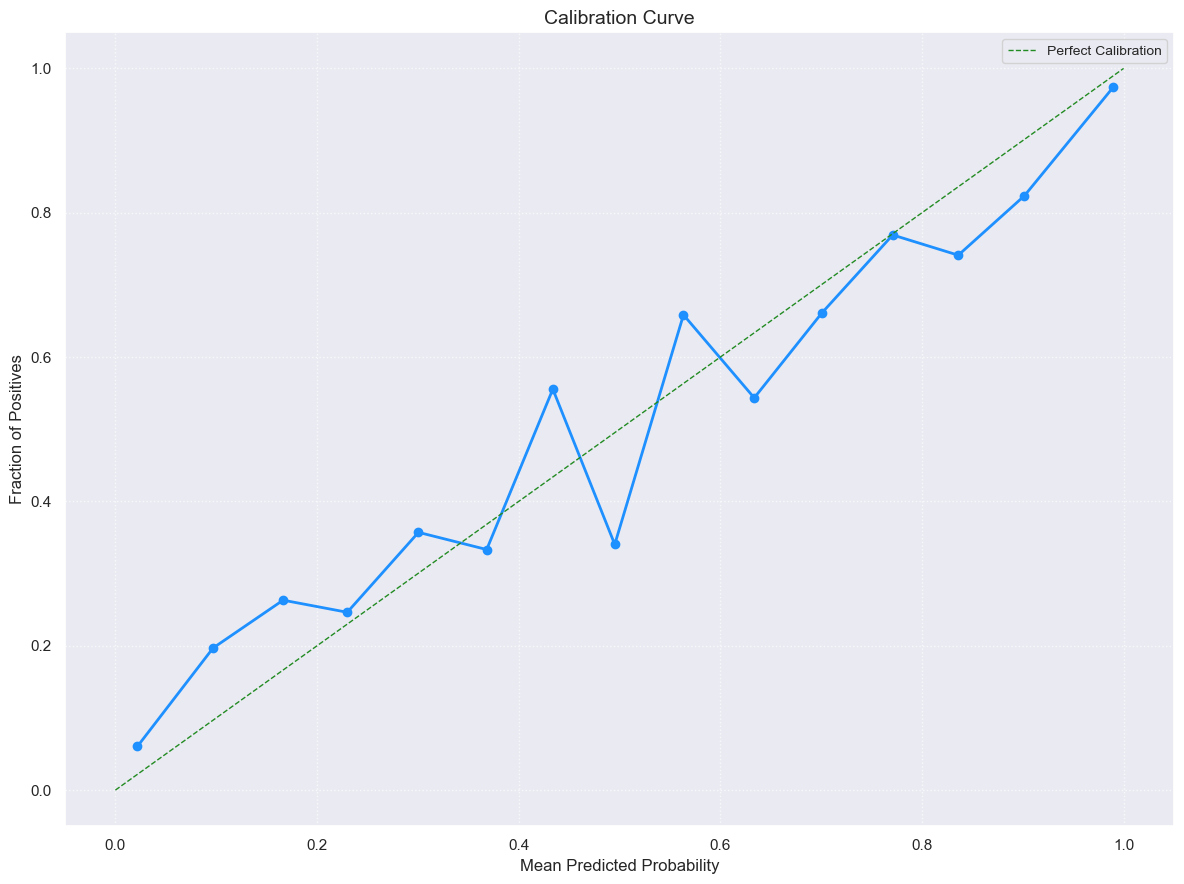

In [206]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

logreg_preds = model.predict_proba(X_test)[:, 1]
logreg_trues, logreg_preds = calibration_curve(y_test, logreg_preds, n_bins=15)

plt.figure(figsize=(12, 9))  
plt.plot(logreg_preds, logreg_trues, color='dodgerblue', marker='o', linestyle='-', linewidth=2, markersize=6)
plt.plot([0, 1], [0, 1], label='Perfect Calibration', linestyle='--', color='forestgreen', linewidth=1)
plt.xlabel('Mean Predicted Probability', fontsize=12) 
plt.ylabel('Fraction of Positives', fontsize=12)
plt.title('Calibration Curve', fontsize=14) 
plt.grid(True, linestyle=':', alpha=0.7)  
plt.legend(fontsize=10) 
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05) 
plt.tight_layout()
plt.show()

**Вывод:** логистическая регрессия откалибрована, наш бустинг неоткалиброван 

## Социализационный бонус. Новогоднее 🎆 (0.5 балла)

Сфотографируйтесь с наряженной новогодней или рождественской ёлкой! Приложите фотографию, опишите свои впечатления, чего вы ждете от нового 2025 года?

<a href="https://ibb.org.ru/1/qTOIa5">
  <img src="https://ibb.org.ru/images/2024/12/22/5422493265032242617.jpg" 
       alt="5422493265032242617.jpg" 
       border="0" 
       width="300" 
       height="200">
</a>

Чего жду?

1. Спать минимум 9 часов
2. Пережить перебор кредитов на 3 курсе, чтобы на 4 - жить на 10 кредитов и в уник ездить чисто побазарить
3. ПЖ можно ЗП 150K+ ну правда очень хочется
4. ~~А вообще лучше всего отель на берегу моря и вообще больше не работать~~

# *𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚*𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚*𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚*𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚*𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚